In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import polars as pl
from math import log
import matplotlib.pyplot as plt
import os
import gc
from ydata_profiling import ProfileReport
from sklearn.feature_selection import r_regression , f_classif
from  sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler , StandardScaler
import polars.selectors as cs

In [3]:
trips_df = pl.read_csv(source="data/trips_dataset.csv" , infer_schema_length = 10000)

individuals_df = pl.read_csv(source="data/individuals_dataset.csv" , infer_schema_length=10000)

In [4]:
trips_df.shape , individuals_df.shape

((80697, 27), (3337, 27))

In [5]:
individuals_with_trips_df = individuals_df.join(other = trips_df, on=["ID"], how ="inner" , suffix="_right" , coalesce=True)

In [6]:
individuals_with_trips_df

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,i64,str,str,i64,str,i64,str,i64,i64,f64,f64,i64,i64,bool,bool,i64,str,str,str,bool,bool,bool,bool,bool,f64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-monday-44851-PDD""","""monday""","""2022-10-17""","""Normal""","""No_Trip""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,97.171946
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-1""","""tuesday""","""2022-10-18""","""Strike""","""1""","""Internal""","""SAVIGNY-SUR-ORGE""","""SAINT-MAUR-DES-FOSSES""","""91589""","""94068""","""OS""","""IS""","""2022-10-18""","""07:29:00""","""2022-10-18""","""08:41:00""",72.0,"""DEPART_HOME""","""OTHER""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-2""","""tuesday""","""2022-10-18""","""Strike""","""2""","""Internal""","""SAINT-MAUR-DES-FOSSES""","""SAINTE-GENEVIEVE-DES-BOIS""","""94068""","""91549""","""IS""","""OS""","""2022-10-18""","""10:48:00""","""2022-10-18""","""11:27:00""",39.0,"""OTHER""","""LEISURE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-3""","""tuesday""","""2022-10-18""","""Strike""","""3""","""Internal""","""SAINTE-GENEVIEVE-DES-BOIS""","""EPINAY-SUR-ORGE""","""91549""","""91216""","""OS""","""OS""","""2022-10-18""","""13:23:00""","""2022-10-18""","""13:40:00""",17.0,"""LEISURE""","""PURCHASE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-4""","""tuesday""","""2022-10-18""","""Strike""","""4""","""Internal""","""EPINAY-SUR-ORGE""","""SAVIGNY-SUR-ORGE""","""91216""","""91589""","""OS""","""OS""","""2022-10-18""","""14:08:00""","""2022-10-18""","""14:14:00""",6.0,"""PURCHASE""","""RETURN_HOME""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4_2386""",77359,"""Perthes""","""Woman""",21,null,7,"""Living with one or both parent…",6,0,3.0,1.0,2,0,false,true,3,"""2""","""0""","""0""",false,false,false,false,false,887.395126,true,"""4_2386-sunday-44955-2""","""sunday""","""2023-01-29""","""Normal""","""2""","""Internal""","""MASSY""","""PERTHES""","""91377""","""77359""","""OS""","""OS""","""2023-01-29""","""12:58:00""","""2023-01-29""","""13:34:00""",36.0,"""ACCOM""","""RETURN_HOME""","""PRIV_CAR_DRIVER""","""PRIV_CAR_DRIVER""",null,null,null,null,124.509471
"""4_2386"

In [7]:
individuals_with_trips_df.describe()

statistic,ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,str,f64,str,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64
"""count""","""80697""",80697.0,"""80697""","""80697""",80697.0,"""67863""",80697.0,"""80697""",80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,80364.0,80697.0,"""80697""","""80697""","""80697""",78614.0,80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,"""80697""","""80697""","""80697""","""80697""","""80697""","""77002""","""76717""","""76717""","""76717""","""76717""","""76301""","""76203""","""76718""","""76696""","""76718""","""76688""",76667.0,"""76718""","""76718""","""76718""","""76648""","""8375""","""2212""","""235""","""20""",80696.0
"""null_count""","""0""",0.0,"""0""","""0""",0.0,"""12834""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,333.0,0.0,"""0""","""0""","""0""",2083.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""3695""","""3980""","""3980""","""3980""","""3980""","""4396""","""4494""","""3979""","""4001""","""3979""","""4009""",4030.0,"""3979""","""3979""","""3979""","""4049""","""72322""","""78485""","""80462""","""80677""",1.0
"""mean""",null,85852.295909,null,null,42.838036,null,3.909228,null,2.545919,0.449967,0.335849,0.27975,1.237283,0.112867,0.032715,0.85817,1.061477,null,null,null,0.519831,0.093523,0.050993,0.111516,0.01953,2690.826792,0.996295,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,24.845696,null,null,null,null,null,null,null,null,407.519873
"""std""",null,8259.760338,null,null,14.394951,null,2.03322,null,1.496899,0.856357,0.658389,0.599805,0.874884,0.401618,null,null,0.89266,null,null,null,null,null,null,null,null,2821.572783,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,27.442536,null,null,null,null,null,null,null,null,443.426629
"""min""","""10_2978""",75101.0,"""Ablis""","""Man""",16.0,"""3–4-year higher education degr…",1.0,"""Another family member in the h…",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,343.084713,0.0,"""10_2978-friday-45002-1""","""friday""","""2022-10-15""","""Bridge day""","""1""","""External""","""ABBEVILLE-LA-RIVIERE""","""ABBEVILLE-LA-RIVIERE""","""01053""","""01369""","""IS""","""IS""","""2022-05-12""","""00:00:00""","""2022-05-12""","""00:00:00""",1.0,"""ACCOM""","""ACCOM""","""BIKE""","""BIKE""","""BIKE""","""BIKE""","""BIKE""","""BIKE""",0.0
"""25%""",null,77215.0,null,null,32.0,null,2.0,null,1.0,0.0,0.0,0.0,1.0,0.0,null,null,0.0,null,null,null,null,null,null,null,null,965.907327,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,8.0,null,null,null,null,null,null,null,null,124.509471
"""50%""",null,91338.0,null,null,43.0,null,3.0,null,2.0,0.0,0.0,0.0,1.0,0.0,null,null,1.0,null,null,null,null,null,null,null,null,1708.918352,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,16.0,null,null,null,null,null,null,null,null,256.714372
"""75%""",null,93051.0,null,null,53.0,null,6.0,null,4.0,1.0,0.0,0.0,2.0,0.0,null,null,2.0,null,null,null,null,null,null,null,null,3070.14298,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,32.0,null,null,null,null,null,null,null,null,462.750015
"""max""","""7_2976""",95680.0,"""Yerres""","""Woman""",82.0,"""Vocational certificate (CAP, B…",8.0,"""Single parent (divorced / sepa…",12.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,8.0,"""4+""",""

In [8]:
individuals_with_trips_df.null_count()

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,12834,0,0,0,0,0,0,0,0,0,333,0,0,0,0,2083,0,0,0,0,0,0,0,0,0,0,0,3695,3980,3980,3980,3980,4396,4494,3979,4001,3979,4009,4030,3979,3979,3979,4049,72322,78485,80462,80677,1


In [9]:
dtypes_dict = {col: individuals_with_trips_df[col].dtype for col in individuals_with_trips_df.columns}
dtypes_dict


{'ID': String,
 'CODGEO': Int64,
 'AREA_NAME': String,
 'SEX': String,
 'AGE': Int64,
 'DIPLOMA': String,
 'PRO_CAT': Int64,
 'TYPE_HOUSE': String,
 'NBPERS_HOUSE': Int64,
 'NB_10': Int64,
 'NB_11_17': Float64,
 'NB_18_24': Float64,
 'NB_25_64': Int64,
 'NB_65': Int64,
 'PMR': Boolean,
 'DRIVING_LICENCE': Boolean,
 'NB_CAR': Int64,
 'TWO_WHEELER': String,
 'BIKE': String,
 'ELECT_SCOOTER': String,
 'NAVIGO_SUB': Boolean,
 'IMAGINER_SUB': Boolean,
 'OTHER_SUB_PT': Boolean,
 'BIKE_SUB': Boolean,
 'NSM_SUB': Boolean,
 'WEIGHT_INDIV': Float64,
 'GPS_RECORD': Boolean,
 'KEY': String,
 'Day_EMG': String,
 'Date_EMG': String,
 'Day_Type': String,
 'ID_Trip_Days': String,
 'Type_Trip_OD': String,
 'Area_O': String,
 'Area_D': String,
 'Code_INSEE_O': String,
 'Code_INSEE_D': String,
 'Zone_O': String,
 'Zone_D': String,
 'Date_O': String,
 'Time_O': String,
 'Date_D': String,
 'Time_D': String,
 'Duration': Float64,
 'Purpose_O': String,
 'Purpose_D': String,
 'Main_Mode': String,
 'Mode_1': S

In [10]:
individuals_with_trips_df.filter(pl.col("GPS_RECORD") == False).height/individuals_with_trips_df.shape[0]/100


3.705218285685961e-05

In [11]:
individuals_with_trips_df = individuals_with_trips_df.filter(pl.col("GPS_RECORD") == True)

individuals_with_trips_df = individuals_with_trips_df.with_columns([
    pl.col("Date_EMG").str.to_date(strict=False),
    pl.col("Date_O").str.to_date(strict=False),
    pl.col("Date_D").str.to_date(strict=False),
    pl.col("Time_O").str.to_time(strict=False),
    pl.col("Time_D").str.to_time(strict=False),
    ]
)

## Encoding Values & Preparing Values for building social vulnerability index (SVI)

### Converting Values to be ready for calculations

In [12]:
"""

for col in are_correlated.select(cs.string()):
        print(col.name ,"  ---------->  " , col.n_unique())

#OUTPUT:
    SEX   ---------->   2
    DIPLOMA   ---------->   7
    TWO_WHEELER   ---------->   5
    BIKE   ---------->   5
    ELECT_SCOOTER   ---------->   5

"""
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
    pl.col("SEX").replace({"Man":0 , "Woman":1} ,return_dtype=pl.Int8),

    pl.col("DIPLOMA").replace({
    "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": 6,
    "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": 5,
    "Upper secondary diploma (Baccalauréat) or equivalent": 4,
    "Vocational certificate (CAP, BEP) or equivalent": 3,
    "Lower secondary certificate (Brevet) or equivalent": 2,
    "No diploma": 1

                        },default=0).cast(pl.Int8),

    pl.col("TWO_WHEELER").replace({"4+":4}, return_dtype=pl.Int8),
    pl.col("BIKE").replace({"4+":4}, return_dtype=pl.Int8),
    pl.col("ELECT_SCOOTER").replace({"4+":4}, return_dtype=pl.Int8),

    #"NAVIGO_SUB", "IMAGINER_SUB", "OTHER_SUB_PT" , "BIKE_SUB", "NSM_SUB"
    pl.col("NAVIGO_SUB").replace({0:1 , 1:0},default=0).cast(pl.Int8),
    pl.col("IMAGINER_SUB").replace({0:1 , 1:0}),
    pl.col("OTHER_SUB_PT").replace({0:1 , 1:0}),
    pl.col("BIKE_SUB").replace({0:1 , 1:0}),
    pl.col("NSM_SUB").replace({0:1 , 1:0}),

    ]
)

### Applying the decreasing function 1/1+log(x) according to the described relations bet. the features applied on it & the Social Vulnerability Index

In [13]:
mean_age = individuals_with_trips_df["AGE"].mean()
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
    pl.col("AGE").map_elements(lambda
                                   x:  log(1+abs(x-mean_age))

                               ).alias('TRANSFORMED_AGE'),
    ]
)




individuals_with_trips_df = individuals_with_trips_df.with_columns([
    pl.col("NB_CAR").map_elements(lambda x : 1/(1+log(1+x))).alias('TRANSFORMED_NB_CAR'), #added the 1 in the log to avoid the people with no cars
    pl.col("PRO_CAT").map_elements(lambda x : 1/(1+log(x))).alias('TRANSFORMED_PRO_CAT'),
    pl.col("NBPERS_HOUSE").map_elements(lambda x : (log(x))).alias('TRANSFORMED_NBPERS_HOUSE'),
    pl.col("TWO_WHEELER").map_elements(lambda x : 1/(1+log(1+x))).alias('TRANSFORMED_TWO_WHEELER'),
    pl.col("BIKE").map_elements(lambda x : 1/(1+log(1+x))).alias('TRANSFORMED_BIKE'),
    pl.col("ELECT_SCOOTER").map_elements(lambda x : 1/(1+log(1+x))).alias('TRANSFORMED_ELECT_SCOOTER'),
    pl.col("DIPLOMA").map_elements(lambda x : 1/(1+log(1+x))).alias('TRANSFORMED_DIPLOMA'),


])

### Converting Bool Values to Integers

In [14]:
individuals_with_trips_df.cast(dtypes={pl.Boolean:pl.Int8})

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day,TRANSFORMED_AGE,TRANSFORMED_NB_CAR,TRANSFORMED_PRO_CAT,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,TRANSFORMED_DIPLOMA
str,i64,str,i8,i64,i8,i64,str,i64,i64,f64,f64,i64,i64,i8,i8,i64,i8,i8,i8,i8,i8,i8,i8,i8,f64,i8,str,str,date,str,str,str,str,str,str,str,str,str,date,time,date,time,f64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,0,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,0,1,3,2,4,0,1,1,1,1,1,786.094977,1,"""42_0001-monday-44851-PDD""","""monday""",2022-10-17,"""Normal""","""No_Trip""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,97.171946,1.148615,0.41906,0.590616,1.386294,0.476505,0.383224,1.0,1.0
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,0,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,0,1,3,2,4,0,1,1,1,1,1,786.094977,1,"""42_0001-tuesday-44852-1""","""tuesday""",2022-10-18,"""Strike""","""1""","""Internal""","""SAVIGNY-SUR-ORGE""","""SAINT-MAUR-DES-FOSSES""","""91589""","""94068""","""OS""","""IS""",2022-10-18,07:29:00,2022-10-18,08:41:00,72.0,"""DEPART_HOME""","""OTHER""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337,1.148615,0.41906,0.590616,1.386294,0.476505,0.383224,1.0,1.0
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,0,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,0,1,3,2,4,0,1,1,1,1,1,786.094977,1,"""42_0001-tuesday-44852-2""","""tuesday""",2022-10-18,"""Strike""","""2""","""Internal""","""SAINT-MAUR-DES-FOSSES""","""SAINTE-GENEVIEVE-DES-BOIS""","""94068""","""91549""","""IS""","""OS""",2022-10-18,10:48:00,2022-10-18,11:27:00,39.0,"""OTHER""","""LEISURE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337,1.148615,0.41906,0.590616,1.386294,0.476505,0.383224,1.0,1.0
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,0,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,0,1,3,2,4,0,1,1,1,1,1,786.094977,1,"""42_0001-tuesday-44852-3""","""tuesday""",2022-10-18,"""Strike""","""3""","""Internal""","""SAINTE-GENEVIEVE-DES-BOIS""","""EPINAY-SUR-ORGE""","""91549""","""91216""","""OS""","""OS""",2022-10-18,13:23:00,2022-10-18,13:40:00,17.0,"""LEISURE""","""PURCHASE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337,1.148615,0.41906,0.590616,1.386294,0.476505,0.383224,1.0,1.0
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,0,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,0,1,3,2,4,0,1,1,1,1,1,786.094977,1,"""42_0001-tuesday-44852-4""","""tuesday""",2022-10-18,"""Strike""","""4""","""Internal""","""EPINAY-SUR-ORGE""","""SAVIGNY-SUR-ORGE""","""91216""","""91589""","""OS""","""OS""",2022-10-18,14:08:00,2022-10-18,14:14:00,6.0,"""PURCHASE""","""RETURN_HOME""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337,1.148615,0.41906,0.590616,1.386294,0.476505,0.383224,1.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4_2386""",77359,"""Perthes""",1,21,0,7,"""Living with one or both parent…",6,0,3.0,1.0,2,0,0,1,3,2,0,0,1,1,1,1,1,887.395126,1,"""4_2386-sunday-44955-2""","""sunday""",2023-01-29,"""Normal""","""2""","""Internal""","""MASSY""","""PERTHES""","""91377""","""77359""","""OS""","""OS""",2023-01-29,12:58:00,2023-01-29,13:34:00,36.0,"""ACCOM""","""RETURN_HOME""","""PRIV_CAR_DRIVER""","""PRIV_CAR_DRIVER""",null,null,null,null,124.509471,3.128784,0.41906,0.339454,1.79175

## Extensive Data Analysis

In [15]:
# ProfileReport(individuals_with_trips_df.to_pandas(),minimal=False , tsmode=False, title="Profiling Report" , explorative=True).to_file("report_after_encoding.html")


In [16]:
are_correlated = individuals_with_trips_df.select(
    pl.col(
        "SEX" , "TRANSFORMED_AGE", "TRANSFORMED_DIPLOMA", "TRANSFORMED_PRO_CAT", "TRANSFORMED_NB_CAR"
        ,"PMR" , "TRANSFORMED_NBPERS_HOUSE" ,
        "TRANSFORMED_TWO_WHEELER", "TRANSFORMED_BIKE", "TRANSFORMED_ELECT_SCOOTER",
        "NAVIGO_SUB", "IMAGINER_SUB", "OTHER_SUB_PT" , "BIKE_SUB", "NSM_SUB"
        )
)

are_correlated.describe()

statistic,SEX,TRANSFORMED_AGE,TRANSFORMED_DIPLOMA,TRANSFORMED_PRO_CAT,TRANSFORMED_NB_CAR,PMR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.550138,2.280117,0.465501,0.482107,0.673307,0.03275,0.760644,0.961723,0.706687,0.960497,0.467673,0.906291,0.949041,0.888442,0.980398
"""std""",0.497483,0.822639,0.235521,0.142114,0.215971,null,0.601321,0.123095,0.263237,0.123549,0.498957,null,null,null,null
"""min""",0.0,0.14308,0.339454,0.324734,0.312771,0.0,0.0,0.383224,0.383224,0.383224,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,1.765788,0.339454,0.358197,0.476505,null,0.0,1.0,0.476505,1.0,0.0,null,null,null,null
"""50%""",1.0,2.472005,0.358197,0.476505,0.590616,null,0.693147,1.0,0.590616,1.0,0.0,null,null,null,null
"""75%""",1.0,2.952502,0.383224,0.590616,1.0,null,1.386294,1.0,1.0,1.0,1.0,null,null,null,null
"""max""",1.0,3.692718,1.0,1.0,1.0,1.0,2.484907,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Making It Ready to Build SVI (Social Vulnerability Index)

In [17]:
cols_2_continue_operations_on = are_correlated.columns


### Normalizing All Features separately by min_max scaler to make each of them particicpate equally in the MVI

In [18]:
for col in cols_2_continue_operations_on:
    if are_correlated[col].n_unique()>2:
        scaler = StandardScaler(with_mean=False, with_std=True)

        scaled_values = scaler.fit_transform(X=are_correlated[col].to_numpy().reshape(-1, 1))

        are_correlated = are_correlated.with_columns(
            pl.Series(col, scaled_values.flatten(), dtype=pl.Float64)
        )
# without scaling the features with higher variance will dominate the weights made by PCA
#PCA is a data reduction technique that transforms the data into a new coordinate system where the greatest variance comes to lie on the first coordinates (principal components) and the least variance on the last coordinates.

In [19]:
"""# --- Your Data Prep and Scaling is done ---
import pandas as pd
# 1. Define your final list of features IN THE EXACT ORDER you will use them.
# This list is your single source of truth for ordering.
final_feature_columns = cols_2_continue_operations_on

# 2. Create your NumPy array FROM THIS LIST to guarantee the order.
X_scaled = are_correlated.select(final_feature_columns).to_numpy()

# 3. Run PCA as before
pca = PCA(n_components=1)
pca.fit(X_scaled)
raw_weights = pca.components_[0]

# 4. Perform the Sign-Flip Check (as discussed before)
# ... code to check a key weight and multiply raw_weights by -1 if needed ...
final_weights = raw_weights# your corrected weights vector

# 5. THE VALIDATION STEP: Create a human-readable map.
# This is your proof that everything is correct.
weight_mapping = pd.Series(final_weights, index=final_feature_columns)

# 6. PRINT and INSPECT this map. This is your moment of truth.
print("--- PCA Component Weights Validation ---")
print(weight_mapping.sort_values(ascending=False))

# **What this validation gives you:**
# When you print the `weight_mapping` series, you will get an unambiguous output like this:

"""

'# --- Your Data Prep and Scaling is done ---\nimport pandas as pd\n# 1. Define your final list of features IN THE EXACT ORDER you will use them.\n# This list is your single source of truth for ordering.\nfinal_feature_columns = cols_2_continue_operations_on\n\n# 2. Create your NumPy array FROM THIS LIST to guarantee the order.\nX_scaled = are_correlated.select(final_feature_columns).to_numpy()\n\n# 3. Run PCA as before\npca = PCA(n_components=1)\npca.fit(X_scaled)\nraw_weights = pca.components_[0]\n\n# 4. Perform the Sign-Flip Check (as discussed before)\n# ... code to check a key weight and multiply raw_weights by -1 if needed ...\nfinal_weights = raw_weights# your corrected weights vector\n\n# 5. THE VALIDATION STEP: Create a human-readable map.\n# This is your proof that everything is correct.\nweight_mapping = pd.Series(final_weights, index=final_feature_columns)\n\n# 6. PRINT and INSPECT this map. This is your moment of truth.\nprint("--- PCA Component Weights Validation ---")\np

In [20]:
pca = PCA(n_components=1)

X = are_correlated.to_numpy()

pca.fit(X)

weights = pca.components_[0]


for i, col in enumerate(cols_2_continue_operations_on):
    are_correlated = are_correlated.with_columns(
        pl.col(col).map_elements(
            lambda x: abs(x * weights[i])
        )
    )


In [21]:
are_correlated.describe()

statistic,SEX,TRANSFORMED_AGE,TRANSFORMED_DIPLOMA,TRANSFORMED_PRO_CAT,TRANSFORMED_NB_CAR,PMR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.001395,1.058823,0.129628,0.7456,1.399845,0.000286,0.662889,1.951938,1.198228,1.79576,0.042761,0.027156,0.002427,0.026677,0.000623
"""std""",0.001262,0.382011,0.065585,0.219786,0.449016,0.001556,0.524042,0.249837,0.446333,0.230989,0.045622,0.008732,0.000562,0.009453,0.000088
"""min""",0.0,0.066442,0.094527,0.502216,0.65027,0.0,0.0,0.777802,0.649778,0.716482,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,0.819983,0.094527,0.553968,0.990682,0.0,0.0,2.029626,0.807942,1.869616,0.0,0.029964,0.002557,0.030027,0.000635
"""50%""",0.002537,1.147931,0.099747,0.736937,1.227925,0.0,0.604067,2.029626,1.001423,1.869616,0.0,0.029964,0.002557,0.030027,0.000635
"""75%""",0.002537,1.37106,0.106716,0.913415,2.079058,0.0,1.208134,2.029626,1.695556,1.869616,0.091434,0.029964,0.002557,0.030027,0.000635
"""max""",0.002537,1.714796,0.278469,1.546546,2.079058,0.008744,2.165558,2.029626,1.695556,1.869616,0.091434,0.029964,0.002557,0.030027,0.000635


## Building the MVI

### Normalizing all Features bet. 0 & 1 to make all features particicpate equally in building the SVI

In [22]:
for col in cols_2_continue_operations_on:
    scaler = MinMaxScaler()

    scaled_values = scaler.fit_transform(X=are_correlated[col].to_numpy().reshape(-1, 1))

    are_correlated = are_correlated.with_columns(
        pl.Series(col, scaled_values.flatten(), dtype=pl.Float64)
    )

In [23]:
are_correlated = are_correlated.with_columns(sum=pl.sum_horizontal(cols_2_continue_operations_on))

are_correlated = are_correlated.rename({"sum":"SVI_raw"})

In [24]:
xx

NameError: name 'xx' is not defined

## Critical Visualization

In [24]:
os.makedirs('plots', exist_ok=True)
os.makedirs('plots/relationships_with_svi' , exist_ok=True)
os.makedirs('plots/relationships_with_transformations', exist_ok=True)

In [25]:
# Create a more informative scatter plot
def plot_transformation_relationship(original_data, transformed_data, feature_name):
    """
    Create a plot showing the relationship between original and transformed features

    Parameters:
    -----------
    original_data : polars.DataFrame
        DataFrame containing the original feature
    transformed_data : polars.DataFrame
        DataFrame containing the transformed feature
    feature_name : str
        Name of the feature (without 'TRANSFORMED_' prefix)
    """
    # Set style parameters
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    # Calculate means
    original_mean = original_data[feature_name].mean()
    transformed_mean = transformed_data[f"TRANSFORMED_{feature_name}"].mean()

    # Create main scatter plot
    scatter = plt.scatter(x=original_data[feature_name],
                          y=transformed_data[f"TRANSFORMED_{feature_name}"],
                          alpha=0.6,
                          label='Data Points')

    # Add mean lines
    plt.axhline(y=transformed_mean, color='red', linestyle='--',
                label=f'Mean Transformed: {transformed_mean:.2f}')
    plt.axvline(x=original_mean, color='blue', linestyle='--',
                label=f'Mean Original: {original_mean:.2f}')

    # Add colorbar scatter
    colorbar_scatter = plt.scatter(x=original_data[feature_name],
                                   y=transformed_data[f"TRANSFORMED_{feature_name}"],
                                   c=original_data[feature_name],
                                   cmap='viridis',
                                   alpha=0.6)

    # Styling
    plt.title(f'Relationship Between {feature_name} and Transformed {feature_name}')
    plt.xlabel(f'Original {feature_name}')
    plt.ylabel(f'Transformed {feature_name}')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')

    # Add colorbar
    cbar = plt.colorbar(colorbar_scatter)
    cbar.set_label(f'Original {feature_name}')

    # Improve layout
    plt.tight_layout()

    # Save the plot
    plt.savefig(f"plots/relationships_with_transformations/transformation_{feature_name}.png", bbox_inches='tight', facecolor='white')
    plt.close()

# Example usage:
for feature in [ "AGE", "DIPLOMA", "PRO_CAT", "NB_CAR", "NBPERS_HOUSE" , "TWO_WHEELER", "BIKE", "ELECT_SCOOTER"]:
    plot_transformation_relationship(individuals_with_trips_df, are_correlated, feature)


In [26]:
def create_styled_scatter_plot(data, feature_name, target="SVI_raw"):
    """
    Create a beautifully styled scatter plot with proper color scaling and means
    """
    # Set style parameters
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

    # Calculate means
    svi_mean = data[target].drop_nans().mean()
    feature_mean = data[feature_name].mean()

    # Create main scatter plot
    original_feature = feature_name.replace('TRANSFORMED_', '')

    # Main scatter plot
    scatter = plt.scatter(x=data[feature_name],
                          y=data[target],
                          c=individuals_with_trips_df[original_feature] if 'TRANSFORMED_' in feature_name else data[feature_name],
                          cmap='viridis',
                          alpha=0.6,
                          s=100,
                          label='Data Points')

    # Add mean lines
    plt.axhline(y=svi_mean, color='red', linestyle='--', label=f'Mean SVI: {svi_mean:.2f}')
    plt.axvline(x=feature_mean, color='blue', linestyle='--', label=f'Mean {feature_name}: {feature_mean:.2f}')

    # Styling
    title = f'Relationship Between {feature_name} and SVI'
    plt.title(title, pad=20, fontsize=14, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Social Vulnerability Index (SVI)', fontsize=12)

    # Grid styling
    plt.grid(True, linestyle='--', alpha=0.3)

    # Add legend with both scatter points and mean lines
    plt.legend(loc='best')

    # Colorbar styling
    cbar = plt.colorbar(scatter)
    cbar.set_label(original_feature if 'TRANSFORMED_' in feature_name else feature_name,
                   fontsize=10,
                   rotation=270,
                   labelpad=15)

    # Improve layout
    plt.tight_layout()

    # Save the plot
    plt.savefig(f"plots/relationships_with_svi/{title}.png", bbox_inches='tight', facecolor='white')
    plt.close()



# Create plots for all features
for col in cols_2_continue_operations_on:
    create_styled_scatter_plot(are_correlated, col)

    # plt.show()


In [29]:
plt.style.use('ggplot')  # Using seaborn style for better aesthetics
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# Calculate means and other statistical measures
original_mean = individuals_with_trips_df["AGE"].mean()
svi_mean = are_correlated["SVI_raw"].mean()

# Create enhanced scatter plot
scatter = plt.scatter(x=individuals_with_trips_df["AGE"],
                      y=are_correlated["SVI_raw"],
                      alpha=0.6,
                      c=individuals_with_trips_df["AGE"],
                      cmap='viridis',
                      s=100,  # Larger point size
                      label='Individual Data Points')

# Add mean lines with improved styling
plt.axvline(x=original_mean, color='blue', linestyle='--', linewidth=2,
            label=f'Mean Age: {original_mean:.1f} years')
plt.axhline(y=svi_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean SVI: {svi_mean:.3f}')

# Enhanced styling
plt.title('Age vs Social Vulnerability Index (SVI)', fontsize=16, pad=20)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Social Vulnerability Index', fontsize=12)
plt.grid(True, alpha=0.3, linestyle=':')

# Improved legend
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Add colorbar with better formatting
cbar = plt.colorbar(scatter)
cbar.set_label('Age (years)', fontsize=10, rotation=270, labelpad=15)

# Add text box with statistical information
stats_text = f'Statistics:\n' \
             f'Age Range: [{individuals_with_trips_df["AGE"].min():.0f}-{individuals_with_trips_df["AGE"].max():.0f}]\n' \
             f'SVI Range: [{are_correlated["SVI_raw"].min():.2f}-{are_correlated["SVI_raw"].max():.2f}]'
plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
         fontsize=10, verticalalignment='top')

# Improve layout with more space for the colorbar
plt.tight_layout()

plt.savefig('plots/age_vs_svi.png', bbox_inches='tight', facecolor='white')
plt.close()

In [27]:
are_correlated.shape

(80398, 16)

In [28]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [29]:
are_correlated.describe()

statistic,SEX,TRANSFORMED_AGE,TRANSFORMED_DIPLOMA,TRANSFORMED_PRO_CAT,TRANSFORMED_NB_CAR,PMR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,SVI_raw
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.550138,0.602044,0.190822,0.233053,0.524623,0.03275,0.306106,0.93794,0.524442,0.935952,0.467673,0.906291,0.949041,0.888442,0.980398,9.029714
"""std""",0.497483,0.231753,0.356554,0.210457,0.314263,0.177982,0.241989,0.199579,0.426795,0.200314,0.498957,0.291425,0.219915,0.314823,0.138631,1.11223
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.857768
"""25%""",0.0,0.457148,0.0,0.049555,0.238253,0.0,0.0,1.0,0.15124,1.0,0.0,1.0,1.0,1.0,1.0,8.333417
"""50%""",1.0,0.656102,0.028376,0.224758,0.404297,0.0,0.278943,1.0,0.336252,1.0,0.0,1.0,1.0,1.0,1.0,9.042128
"""75%""",1.0,0.791467,0.066264,0.393744,1.0,0.0,0.557886,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.769172
"""max""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12.466731


#### Plotting the SVI Distribution on MAP

🗺️  Creating Clean Compact SVI Choropleth Map...
⚙️  Features: Beautiful box annotations, clean design, focused view
🎯 Design: Compact layout without cluttered district names
Clean compact map saved to clean_compact_svi_map.png


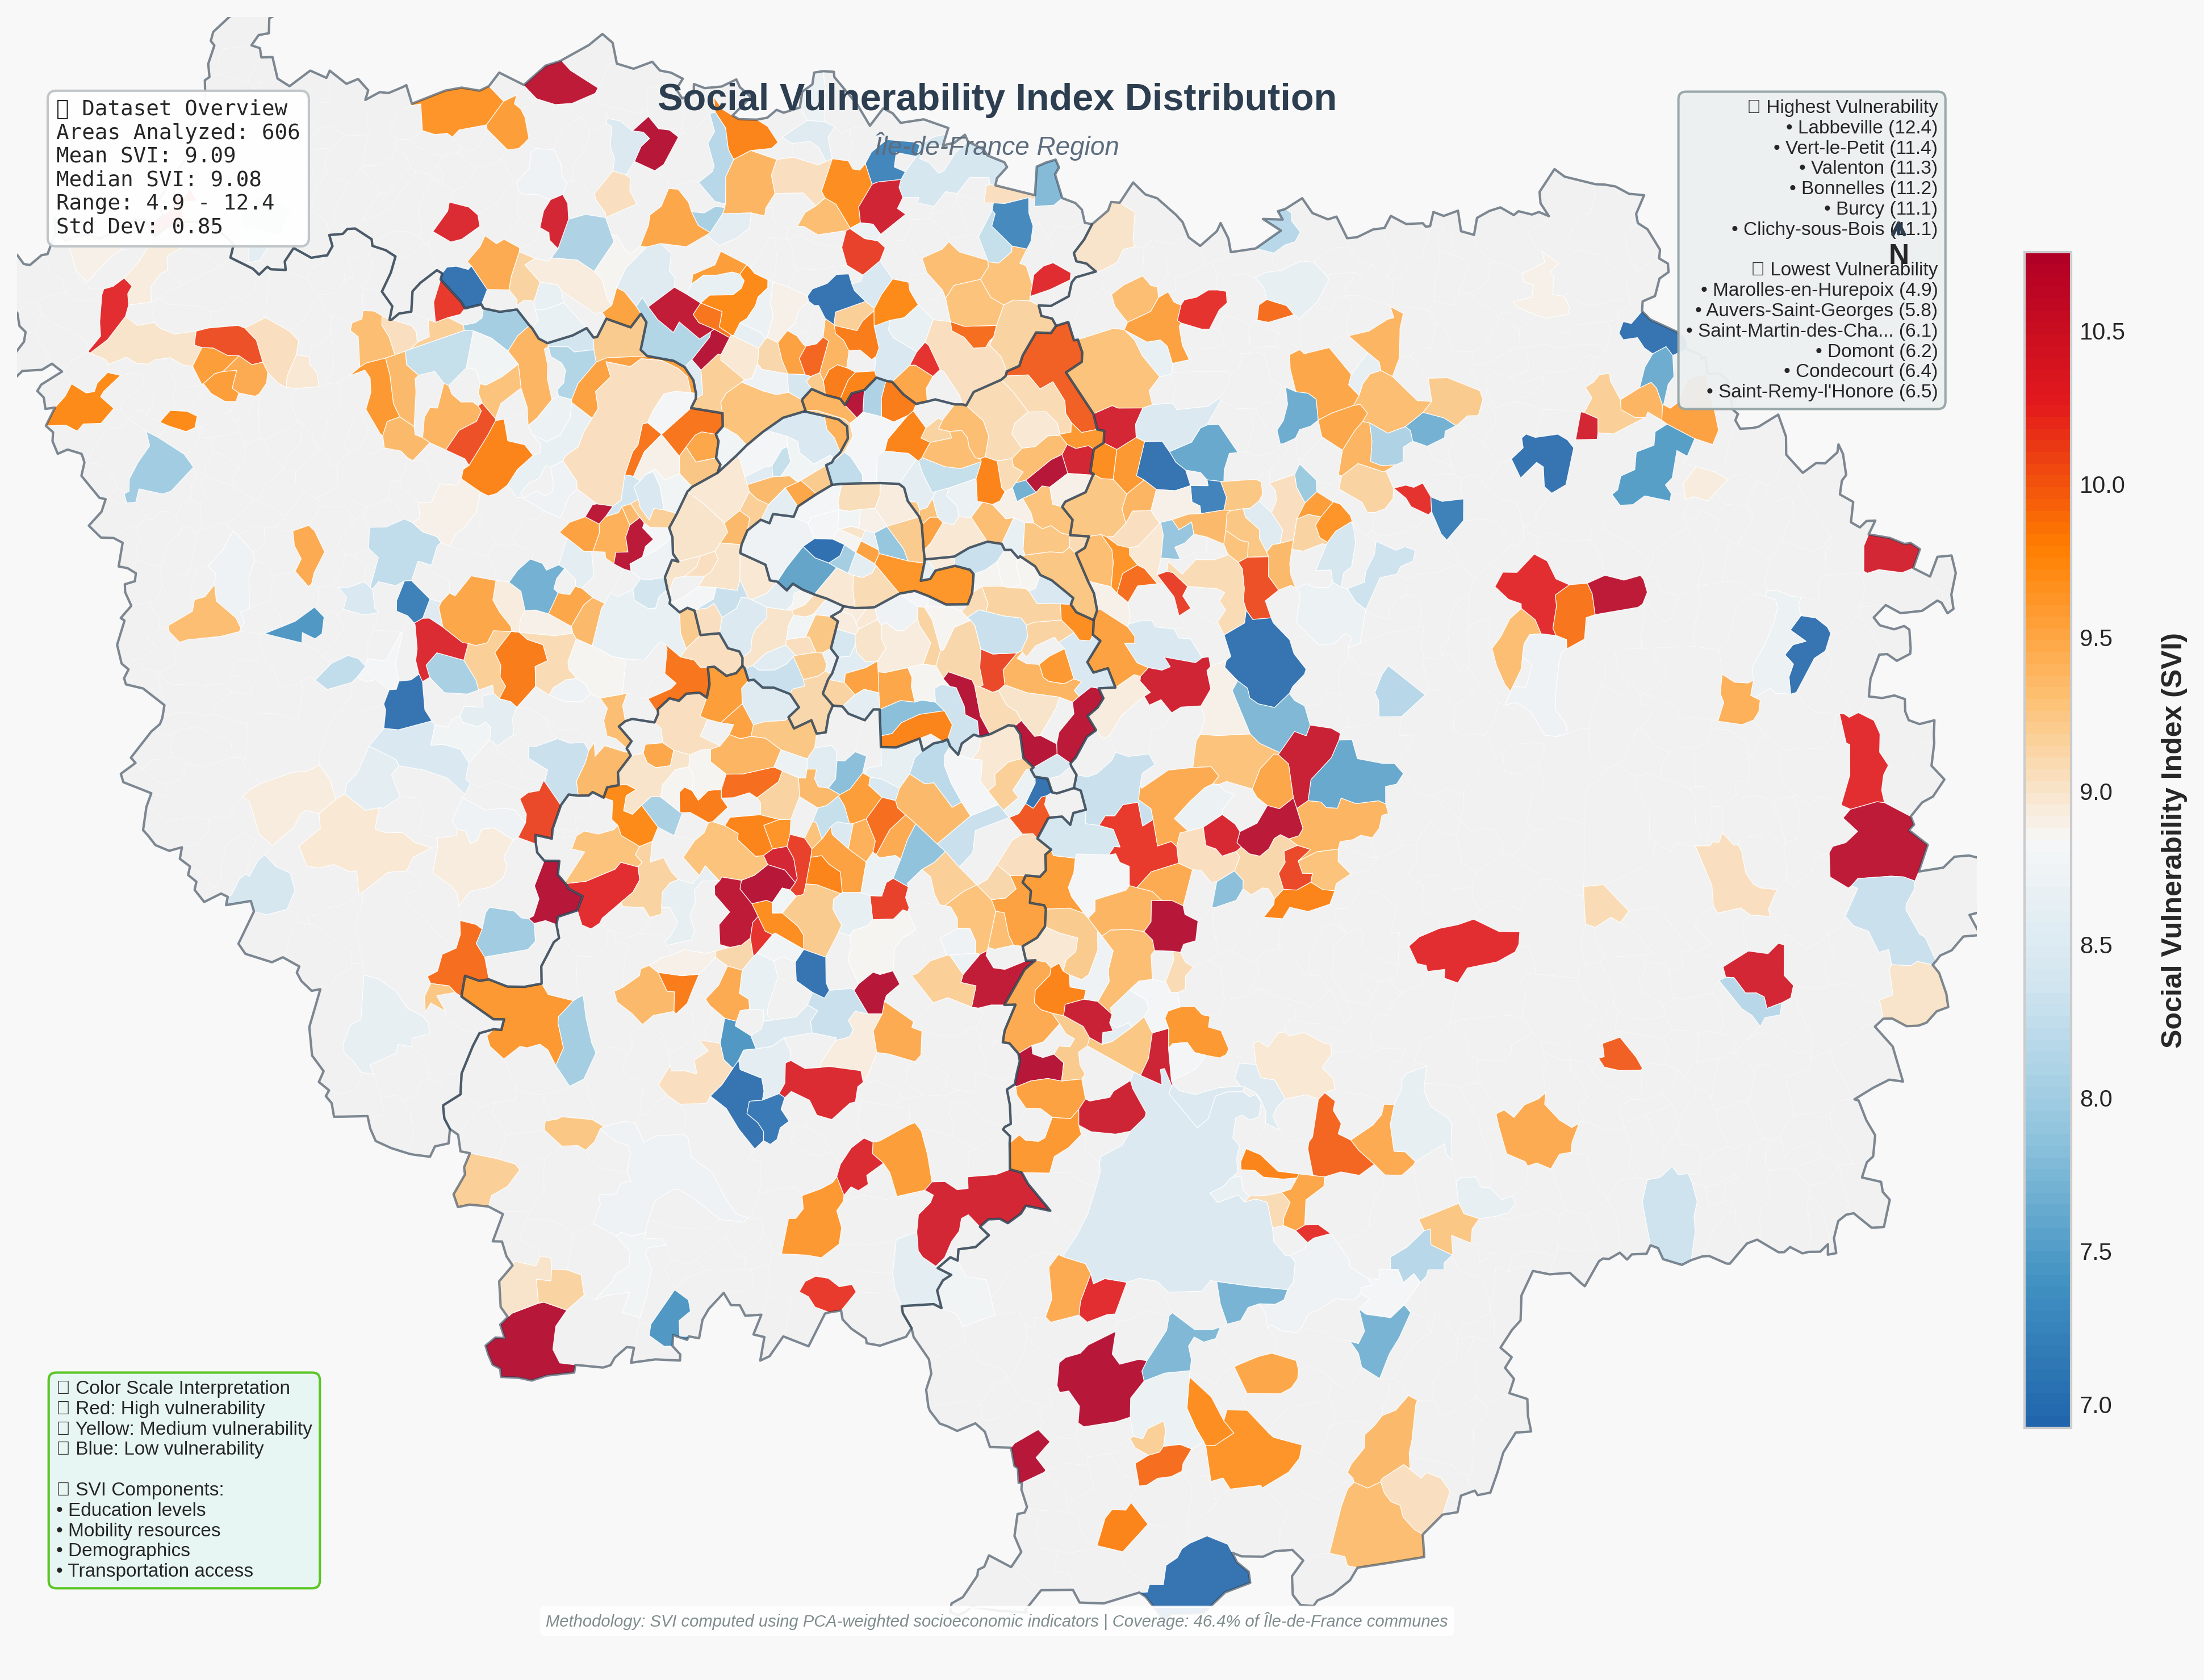


📊 SVI DISTRIBUTION ANALYSIS
🗺️  Areas Analyzed: 606 communes
📈 Coverage: 46.4% of Île-de-France
📊 Mean SVI: 9.09 ± 0.85
📊 Range: 4.9 - 12.4

🔴 TOP 5 MOST VULNERABLE AREAS:
---------------------------------------------
1. Labbeville                | 12.40
2. Vert-le-Petit             | 11.42
3. Valenton                  | 11.34
4. Bonnelles                 | 11.22
5. Burcy                     | 11.11

🔵 TOP 5 LEAST VULNERABLE AREAS:
---------------------------------------------
1. Marolles-en-Hurepoix      |  4.94
2. Auvers-Saint-Georges      |  5.82
3. Saint-Martin-des-Champs   |  6.13
4. Domont                    |  6.17
5. Condecourt                |  6.44

✅ Clean compact visualization complete!
📊 Beautiful box annotations preserved with cleaner map design


In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

def create_clean_compact_svi_choropleth(svi_data, save_path=None):
    """
    Create clean, compact choropleth map with beautiful box annotations
    but without cluttered district names on the map

    Parameters:
    svi_data (DataFrame): DataFrame with 'insee_code', 'svi_score', and 'AREA_NAME' columns
    save_path (str, optional): Path to save the figure

    Returns:
    GeoDataFrame: Merged geographic data with SVI scores
    """

    # Load Île-de-France communes
    geojson_url = "https://france-geojson.gregoiredavid.fr/repo/communes.geojson"
    communes_gdf = gpd.read_file(geojson_url)

    # Filter for Île-de-France departments
    idf_departments = ['75', '77', '78', '91', '92', '93', '94', '95']
    communes_gdf['dept'] = communes_gdf['code'].str[:2]
    idf_gdf = communes_gdf[communes_gdf['dept'].isin(idf_departments)].copy()

    # Process and merge SVI data
    svi_grouped = svi_data.groupby(['insee_code', 'AREA_NAME'])['svi_score'].mean().reset_index()
    svi_grouped['insee_code'] = svi_grouped['insee_code'].astype(str)
    idf_gdf['code'] = idf_gdf['code'].astype(str)

    map_data = idf_gdf.merge(svi_grouped, left_on='code', right_on='insee_code', how='left')
    map_data['svi_score'] = map_data['svi_score'].fillna(0)

    # Filter to areas with data for focused view
    areas_with_data = map_data[map_data['svi_score'] > 0].copy()

    # Apply ggplot style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create compact figure with high DPI
    fig, ax = plt.subplots(1, 1, figsize=(14, 10), dpi=300)

    # Set background color for ggplot feel
    fig.patch.set_facecolor('#F8F8F8')
    ax.set_facecolor('#F8F8F8')

    # Calculate percentiles for better color scaling
    svi_values = areas_with_data['svi_score']
    vmin, vmax = svi_values.quantile([0.02, 0.98]) if len(svi_values) > 0 else (0, 1)

    # Create custom colormap with better contrast
    colors = ['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0', '#F7F7F7',
              '#FDBF6F', '#FF7F00', '#E31A1C', '#B10026']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

    # Plot all areas in light gray first (context)
    map_data.plot(
        ax=ax,
        color='#E8E8E8',
        edgecolor='white',
        linewidth=0.2,
        alpha=0.4
    )

    # Create choropleth for areas with data
    areas_with_data.plot(
        column='svi_score',
        ax=ax,
        cmap=cmap,
        edgecolor='white',
        linewidth=0.3,
        alpha=0.9,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    # Add department boundaries with subtle styling
    dept_boundaries = map_data.dissolve(by='dept')
    dept_boundaries.boundary.plot(ax=ax, color='#2C3E50', linewidth=1.0, alpha=0.6)

    # Set view to focus on areas with data (with some padding)
    if len(areas_with_data) > 0:
        bounds = areas_with_data.total_bounds
        padding = 0.03
        ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
        ax.set_ylim(bounds[1] - padding, bounds[3] + padding)

    # Create custom colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.7, aspect=25, pad=0.02)
    cbar.set_label('Social Vulnerability Index (SVI)',
                   fontsize=12, fontweight='bold', labelpad=15)
    cbar.ax.tick_params(labelsize=10)

    # Clean, compact title
    main_title = 'Social Vulnerability Index Distribution'
    subtitle = 'Île-de-France Region'

    ax.text(0.5, 0.96, main_title,
            transform=ax.transAxes, fontsize=16, fontweight='bold',
            ha='center', va='top', color='#2C3E50')
    ax.text(0.5, 0.93, subtitle,
            transform=ax.transAxes, fontsize=11, style='italic',
            ha='center', va='top', color='#5D6D7E')

    # Compact statistical annotations box
    stats_text = (
        f'📊 Dataset Overview\n'
        f'Areas Analyzed: {len(areas_with_data):,}\n'
        f'Mean SVI: {svi_values.mean():.2f}\n'
        f'Median SVI: {svi_values.median():.2f}\n'
        f'Range: {svi_values.min():.1f} - {svi_values.max():.1f}\n'
        f'Std Dev: {svi_values.std():.2f}'
    )

    ax.text(0.02, 0.95, stats_text,
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95,
                      edgecolor='#BDC3C7', linewidth=1),
            verticalalignment='top',
            fontfamily='monospace')

    # Enhanced top/bottom areas legend with better formatting
    high_svi = areas_with_data.nlargest(6, 'svi_score')
    low_svi = areas_with_data.nsmallest(6, 'svi_score')

    legend_text = (
        f'🔴 Highest Vulnerability\n'
        f'{chr(10).join([f"• {row.AREA_NAME[:20]}{"..." if len(row.AREA_NAME) > 20 else ""} ({row.svi_score:.1f})" for _, row in high_svi.iterrows()])}\n\n'
        f'🔵 Lowest Vulnerability\n'
        f'{chr(10).join([f"• {row.AREA_NAME[:20]}{"..." if len(row.AREA_NAME) > 20 else ""} ({row.svi_score:.1f})" for _, row in low_svi.iterrows()])}'
    )

    ax.text(0.98, 0.95, legend_text,
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ECF0F1', alpha=0.95,
                      edgecolor='#95A5A6', linewidth=1),
            verticalalignment='top', horizontalalignment='right')

    # Compact interpretation guide
    interpretation_text = (
        '🎯 Color Scale Interpretation\n'
        '🔴 Red: High vulnerability\n'
        '🟡 Yellow: Medium vulnerability\n'
        '🔵 Blue: Low vulnerability\n'
        '\n'
        '📈 SVI Components:\n'
        '• Education levels\n'
        '• Mobility resources\n'
        '• Demographics\n'
        '• Transportation access'
    )

    ax.text(0.02, 0.05, interpretation_text,
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F6F3', alpha=0.95,
                      edgecolor='#52C41A', linewidth=1),
            verticalalignment='bottom', horizontalalignment='left')

    # Compact methodology note
    methodology_text = (
        'Methodology: SVI computed using PCA-weighted socioeconomic indicators | '
        f'Coverage: {len(areas_with_data)/len(map_data)*100:.1f}% of Île-de-France communes'
    )

    ax.text(0.5, 0.02, methodology_text,
            transform=ax.transAxes, fontsize=7, style='italic',
            ha='center', va='bottom', color='#7F8C8D',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

    # Remove axes for cleaner look
    ax.set_axis_off()

    # Add subtle grid lines for ggplot feel
    ax.grid(True, alpha=0.1, linestyle='-', linewidth=0.3, color='#BDC3C7')

    # Add compact north arrow
    ax.annotate('N', xy=(0.96, 0.88), xytext=(0.96, 0.85),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=12, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

    # Tight layout with minimal padding
    plt.tight_layout(pad=0.5)

    # Save with high quality if path provided
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight',
                    facecolor='#F8F8F8', edgecolor='none',
                    format='png')
        print(f"Clean compact map saved to {save_path}")

    plt.show()

    # Clean, compact statistics output
    print("\n" + "="*60)
    print("📊 SVI DISTRIBUTION ANALYSIS")
    print("="*60)
    print(f"🗺️  Areas Analyzed: {len(areas_with_data)} communes")
    print(f"📈 Coverage: {len(areas_with_data)/len(map_data)*100:.1f}% of Île-de-France")
    print(f"📊 Mean SVI: {svi_values.mean():.2f} ± {svi_values.std():.2f}")
    print(f"📊 Range: {svi_values.min():.1f} - {svi_values.max():.1f}")

    print(f"\n🔴 TOP 5 MOST VULNERABLE AREAS:")
    print("-" * 45)
    for i, (_, row) in enumerate(high_svi.head(5).iterrows(), 1):
        print(f"{i}. {row['AREA_NAME']:25} | {row['svi_score']:5.2f}")

    print(f"\n🔵 TOP 5 LEAST VULNERABLE AREAS:")
    print("-" * 45)
    for i, (_, row) in enumerate(low_svi.head(5).iterrows(), 1):
        print(f"{i}. {row['AREA_NAME']:25} | {row['svi_score']:5.2f}")

    print("="*60)

    return areas_with_data

# =============================================================================
# CLEAN COMPACT EXECUTION
# =============================================================================

# Update the are_correlated dataframe with area names
are_correlated = are_correlated.with_columns([
    pl.Series("insee_code", individuals_with_trips_df["CODGEO"].cast(pl.Utf8)),
    pl.Series("AREA_NAME", individuals_with_trips_df["AREA_NAME"]),
    pl.Series("svi_score", are_correlated["SVI_raw"].cast(pl.Float64))
])

# Convert to pandas for visualization
svi_data = are_correlated.select(['insee_code', 'svi_score', 'AREA_NAME']).to_pandas()

# Create the clean compact map
print("🗺️  Creating Clean Compact SVI Choropleth Map...")
print("⚙️  Features: Beautiful box annotations, clean design, focused view")
print("🎯 Design: Compact layout without cluttered district names")

result = create_clean_compact_svi_choropleth(svi_data, save_path='clean_compact_svi_map.png')

print("\n✅ Clean compact visualization complete!")
print("📊 Beautiful box annotations preserved with cleaner map design")

## Intuitions & Brainstorming

In [31]:
#1st intuition 1/1+log(age) for ages lower than mean and log(age)-1 for ages above
"""
mean_age = 43
Age 42: 1 / (1 + log(42)) = 1 / (1 + 3.74) = 0.211
Age 44: log(44) - 1 = 3.78 - 1 = 2.78
"""

#2nd idea log(1 + |AGE - μ|) produces u-shaped snooth curve

'\nmean_age = 43\nAge 42: 1 / (1 + log(42)) = 1 / (1 + 3.74) = 0.211\nAge 44: log(44) - 1 = 3.78 - 1 = 2.78\n'

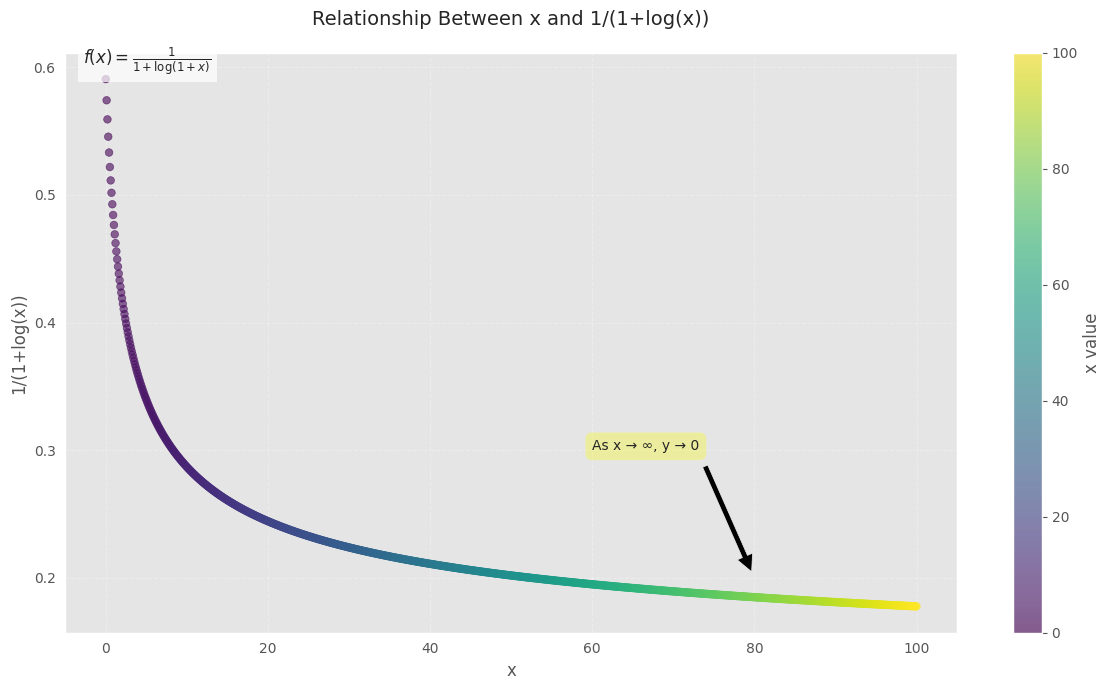

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Set the style
plt.style.use('ggplot')

# Create data points
i_s = np.linspace(0, 100 ,1000)  # More points for smoother curve
product = 1/(1 + np.log1p(1+ i_s))  # np.log1p is more numerically stable than log(1+x)

# Create the plot
plt.figure(figsize=(12, 7))

# Main plot with gradient color
scatter = plt.scatter(i_s, product,
                      c=i_s,  # Color points by i value
                      cmap='viridis',  # Use viridis colormap
                      alpha=0.6,
                      s=30)  # Point size

# Add colorbar
plt.colorbar(scatter, label='x value')

# Customize the plot
plt.title('Relationship Between x and 1/(1+log(x))', fontsize=14, pad=20)
plt.xlabel('x', fontsize=12)
plt.ylabel('1/(1+log(x))', fontsize=12)

# Add grid with custom style
plt.grid(True, linestyle='--', alpha=0.3)

# Add annotations for key points
plt.annotate(f'As x → ∞, y → 0',
             xy=(80, 0.2),
             xytext=(60, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.05),
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

# Add mathematical formula
plt.text(0.02, 0.98, r'$f(x) = \frac{1}{1 + \log(1+x)}$',
         transform=plt.gca().transAxes,
         fontsize=12,
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

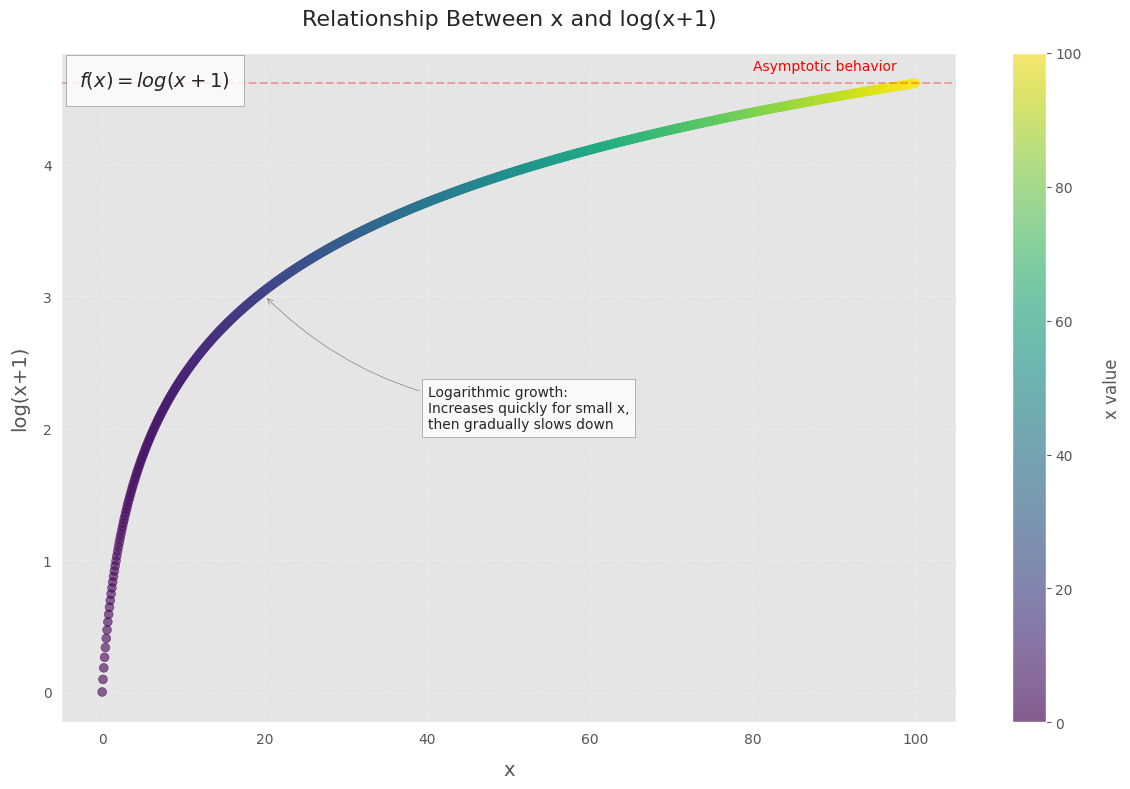

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style with a modern look
plt.style.use('ggplot')

# Create data points with careful range
x = np.linspace(0, 100, 1000)
y = np.log1p(x)  # Using log1p for numerical stability

# Create figure and axis objects with specific size
fig, ax = plt.subplots(figsize=(12, 8))

# Create gradient color mapping
norm = plt.Normalize(x.min(), x.max())
colors = plt.cm.viridis(norm(x))

# Main scatter plot with gradient
scatter = ax.scatter(x, y, c=x, cmap='viridis', alpha=0.6, s=40)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.3)

# Add colorbar with custom styling
cbar = plt.colorbar(scatter)
cbar.set_label('x value', fontsize=12, labelpad=15)
cbar.ax.tick_params(labelsize=10)

# Set labels and title with LaTeX formatting
ax.set_title('Relationship Between x and log(x+1)', fontsize=16, pad=20)
ax.set_xlabel('x', fontsize=14, labelpad=10)
ax.set_ylabel('log(x+1)', fontsize=14, labelpad=10)

# Add tick parameters
ax.tick_params(axis='both', which='major', labelsize=10)

# Add key points annotation
ax.annotate('Logarithmic growth:\nIncreases quickly for small x,\n'
            'then gradually slows down',
            xy=(20, 3),
            xytext=(40, 2),
            fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8),
            arrowprops=dict(arrowstyle='->',
                            connectionstyle='arc3,rad=-.2',
                            color='gray'))

# Add mathematical formula with LaTeX
ax.text(0.02, 0.95, r'$f(x) = log(x+1)$',
        transform=ax.transAxes,
        fontsize=14,
        bbox=dict(facecolor='white',
                  edgecolor='gray',
                  alpha=0.8,
                  pad=10))

# Add horizontal asymptote visualization
ax.axhline(y=np.log1p(100), color='red', linestyle='--', alpha=0.3)
ax.text(80, np.log1p(100) + 0.1, 'Asymptotic behavior',
        fontsize=10, color='red')

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

In [34]:
"""Indicator Group	Variable(s) from Dataset	What It Measures (Proxy for...)
Physical Capacity	PMR, AGE	Direct physical barriers to mobility
Household Resources	NB_CAR, DRIVING_LICENCE, TWO_WHEELER etc.	Access to private, independent transport options
Household Constraints	NBPERS_HOUSE, NB_10, etc.	Presence of dependents complicating evacuation
Socio-Economic Status	DIPLOMA, PRO_CAT	Income, job flexibility, information access
System Dependency	NAVIGO_SUB, etc.	Reliance on public systems that might fail
"""

'Indicator Group\tVariable(s) from Dataset\tWhat It Measures (Proxy for...)\nPhysical Capacity\tPMR, AGE\tDirect physical barriers to mobility\nHousehold Resources\tNB_CAR, DRIVING_LICENCE, TWO_WHEELER etc.\tAccess to private, independent transport options\nHousehold Constraints\tNBPERS_HOUSE, NB_10, etc.\tPresence of dependents complicating evacuation\nSocio-Economic Status\tDIPLOMA, PRO_CAT\tIncome, job flexibility, information access\nSystem Dependency\tNAVIGO_SUB, etc.\tReliance on public systems that might fail\n'

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pynsee.geodata import get_geodata, get_geodata_list
import numpy as np
import os

os.environ['sirene_key'] = '8443bcd3-ebf5-4a54-83bc-d3ebf51a546f'

# Step 1: Explore available geodata and find commune identifiers
print("Available geodata types:")
geodata_list = get_geodata_list()

# Find commune-related identifiers
commune_identifiers = []
for _, row in geodata_list.iterrows():
    if 'commune' in row['Identifier'].lower():
        commune_identifiers.append(row['Identifier'])

print(f"\nFound {len(commune_identifiers)} commune identifiers:")
for identifier in commune_identifiers:
    print(f"  - {identifier}")

# Helper function to find the best column name
def find_column_by_pattern(df, patterns):
    """Find a column name that matches any of the given patterns"""
    for col in df.columns:
        for pattern in patterns:
            if pattern.lower() in col.lower():
                return col
    return None

# Step 2: Load your SVI data (replace with your actual data loading)
# Assuming your data has columns: 'insee_code' and 'svi_score'
# svi_data = pd.read_csv('your_svi_data.csv')  # Replace with your actual file

# For demonstration, let's create sample data
# In practice, replace this with your actual data loading
sample_insee_codes = ['75001', '75002', '75003', '92001', '92002', '93001', '94001', '95001']
sample_svi_scores = [150, 200, 180, 220, 190, 250, 210, 170]
svi_data = pd.DataFrame({
    'insee_code': sample_insee_codes,
    'svi_score': sample_svi_scores
})

# Step 3: Group by INSEE codes and sum SVI scores
# If you have multiple rows per INSEE code, this will aggregate them
svi_grouped = svi_data.groupby('insee_code')['svi_score'].sum().reset_index()
print(f"Grouped SVI data shape: {svi_grouped.shape}")
print(svi_grouped.head())

# Step 4: Get geographic data for Île-de-France
# From the geodata list, we need to use the correct identifier
print("\nLooking for commune data in geodata list...")

# Get all communes in France first (we'll filter for Île-de-France later)
# Using the identifier from the geodata list
try:
    # Try the most recent commune data
    idf_geodata = get_geodata('ADMINEXPRESS-COG.LATEST:commune')
    print(f"\nGeodata shape: {idf_geodata.shape}")
    print(f"Columns: {idf_geodata.columns.tolist()}")

    # Display sample of geodata
    print("\nSample of geodata:")
    print(idf_geodata.head())

    # Filter for Île-de-France (region code 11)
    # The region code is usually in a column like 'reg' or 'region'
    region_col = None
    for col in idf_geodata.columns:
        if 'reg' in col.lower():
            region_col = col
            break

    if region_col:
        print(f"\nUsing region column: {region_col}")
        print(f"Unique region values: {sorted(idf_geodata[region_col].unique())}")

        # Filter for Île-de-France (region code 11)
        idf_geodata = idf_geodata[idf_geodata[region_col] == '11'].copy()
        print(f"Filtered data shape for Île-de-France: {idf_geodata.shape}")
    else:
        print("Could not find region column, using all communes")

except Exception as e:
    print(f"Error loading geodata: {e}")
    # Try alternative identifier
    try:
        print("Trying alternative identifier...")
        idf_geodata = get_geodata('ADMINEXPRESS-COG.2017:commune')
        print(f"Alternative geodata shape: {idf_geodata.shape}")
        print(f"Columns: {idf_geodata.columns.tolist()}")

        # Filter for Île-de-France if region column exists
        region_col = None
        for col in idf_geodata.columns:
            if 'reg' in col.lower():
                region_col = col
                break

        if region_col:
            idf_geodata = idf_geodata[idf_geodata[region_col] == '11'].copy()
            print(f"Filtered data shape for Île-de-France: {idf_geodata.shape}")

    except Exception as e2:
        print(f"Alternative approach also failed: {e2}")
        print("Please check available identifiers in the geodata list")

# Step 5: Merge SVI data with geographic data
# Find the INSEE code column using multiple possible patterns
insee_patterns = ['insee', 'com', 'code_insee', 'depcom', 'insee_com']
insee_col = find_column_by_pattern(idf_geodata, insee_patterns)

if insee_col:
    print(f"\nUsing INSEE column: {insee_col}")
    print(f"Sample INSEE codes: {idf_geodata[insee_col].head().tolist()}")

    # Ensure INSEE codes are strings and properly formatted
    idf_geodata[insee_col] = idf_geodata[insee_col].astype(str)
    svi_grouped['insee_code'] = svi_grouped['insee_code'].astype(str)

    # Merge the data
    map_data = idf_geodata.merge(
        svi_grouped,
        left_on=insee_col,
        right_on='insee_code',
        how='left'
    )

    # Fill NaN values with 0 for areas without SVI data
    map_data['svi_score'] = map_data['svi_score'].fillna(0)

    print(f"Merged data shape: {map_data.shape}")
    print(f"Areas with SVI data: {(map_data['svi_score'] > 0).sum()}")

    # Show which INSEE codes from your data were matched
    matched_codes = map_data[map_data['svi_score'] > 0]['insee_code'].unique()
    unmatched_codes = set(svi_grouped['insee_code']) - set(matched_codes)

    print(f"Matched INSEE codes: {sorted(matched_codes)}")
    if unmatched_codes:
        print(f"Unmatched INSEE codes: {sorted(unmatched_codes)}")

else:
    print("Could not find INSEE code column in geodata")
    print("Available columns:", idf_geodata.columns.tolist())

    # If we can't find the INSEE column, show some sample data to help debug
    print("\nSample of geodata to help identify the right column:")
    print(idf_geodata.head())

    # Exit early if we can't find the column
    print("Please check the column names and update the code accordingly.")
    exit()

# Step 6: Create the choropleth map
if 'map_data' in locals() and not map_data.empty:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Create the choropleth map
    map_data.plot(
        column='svi_score',
        ax=ax,
        legend=True,
        cmap='YlOrRd',  # Color map (yellow to red)
        edgecolor='black',
        linewidth=0.1,
        legend_kwds={
            'label': 'SVI Score',
            'orientation': 'vertical',
            'shrink': 0.6
        }
    )

    # Customize the map
    ax.set_title('SVI Scores by District in Île-de-France', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Remove axis ticks for cleaner look
    ax.tick_params(axis='both', which='major', labelsize=8)

    # Add grid
    ax.grid(True, alpha=0.3)

    # Tight layout
    plt.tight_layout()

    # Show the map
    plt.show()

    # Step 7: Print summary statistics
    print(f"\nSVI Score Statistics:")
    print(f"Mean: {map_data['svi_score'].mean():.2f}")
    print(f"Median: {map_data['svi_score'].median():.2f}")
    print(f"Min: {map_data['svi_score'].min():.2f}")
    print(f"Max: {map_data['svi_score'].max():.2f}")
    print(f"Standard deviation: {map_data['svi_score'].std():.2f}")

    # Optional: Save the map
    # plt.savefig('idf_svi_map.png', dpi=300, bbox_inches='tight')

else:
    print("Cannot create map - data merging failed or no data available.")

Existing environment variable sirene_key used, instead of locally saved credentials


Available geodata types:

Found 38 commune identifiers:
  - ADMINEXPRESS-COG.2017:commune
  - ADMINEXPRESS-COG.2018:commune
  - ADMINEXPRESS-COG.2019:commune
  - ADMINEXPRESS-COG.2020:commune
  - ADMINEXPRESS-COG.2021:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2021:chef_lieu_commune
  - ADMINEXPRESS-COG.2021:commune
  - ADMINEXPRESS-COG.2021:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2022:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2022:chef_lieu_commune
  - ADMINEXPRESS-COG.2022:commune
  - ADMINEXPRESS-COG.2022:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2023:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2023:chef_lieu_commune
  - ADMINEXPRESS-COG.2023:commune
  - ADMINEXPRESS-COG.2023:commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2024:chef_lieu_commune_associee_ou_deleguee
  - ADMINEXPRESS-COG.2024:chef_lieu_commune
  - ADMINEXPRESS-COG.2024:commune
  - ADMINEXPRESS-COG.2024:commune_associee_ou_deleguee
  - ADMINEXPRESS

 14%|█▍        | 1/7 [02:32<15:17, 152.86s/it]


KeyboardInterrupt: 

Starting SVI choropleth map creation...
Loaded 35798 communes from France
Filtered to 1297 communes in Île-de-France

Processing SVI data...
SVI data: 598 unique INSEE codes
Merging data...
Merged data: 598 communes with SVI data out of 1297 total
Creating choropleth map...


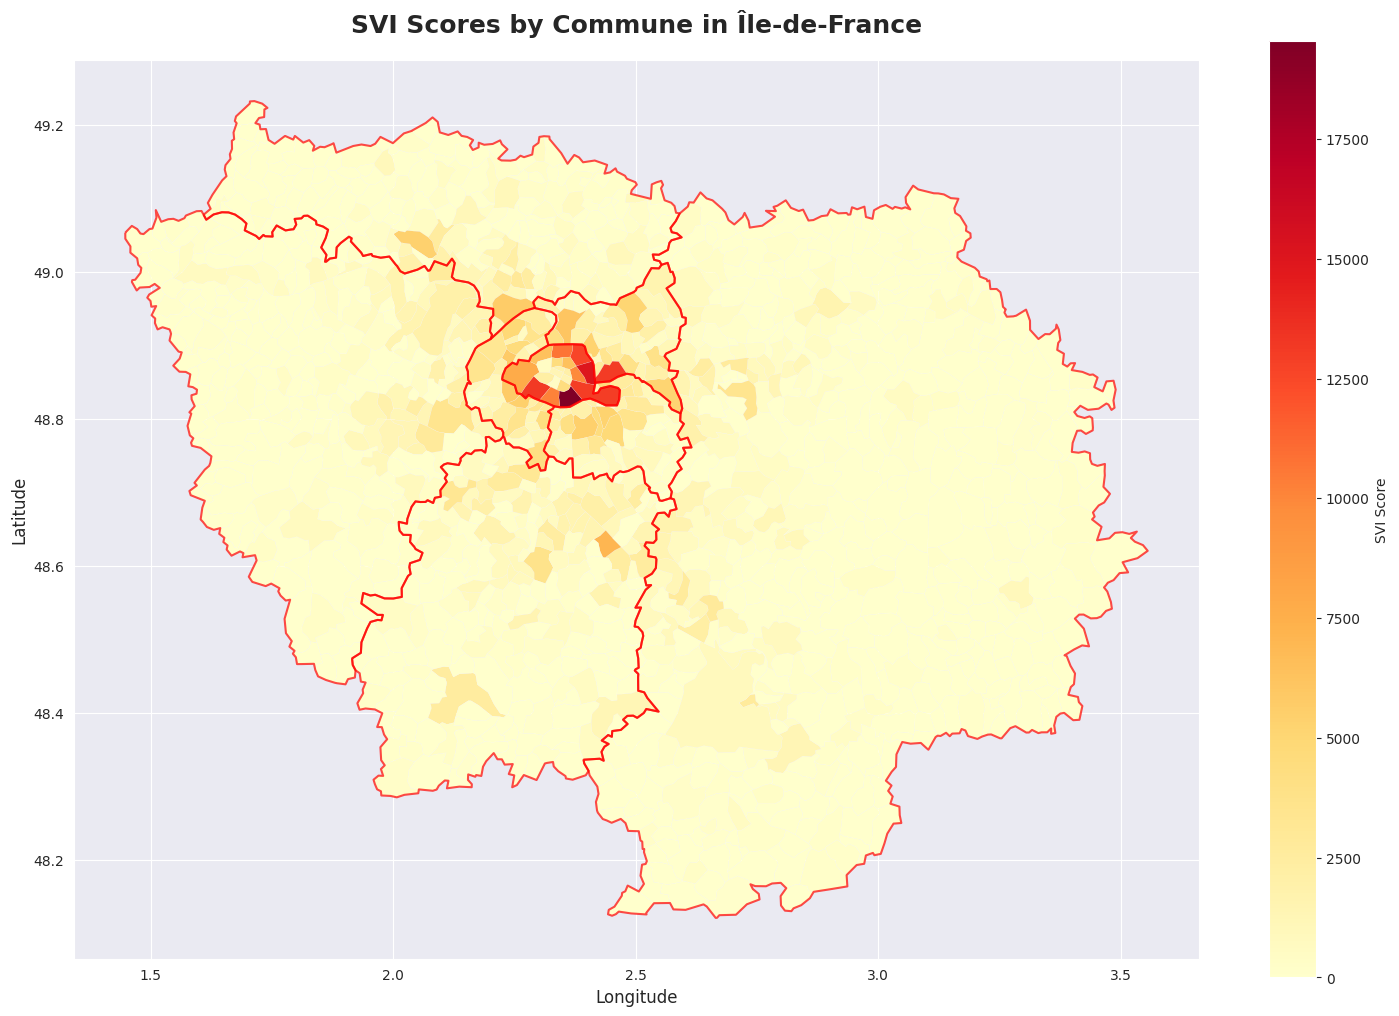


SVI SCORE STATISTICS
Total communes: 1297
Communes with SVI data: 598
Mean SVI score: 559.73
Median SVI score: 0.00
Min SVI score: 0.00
Max SVI score: 19534.43

Top 10 communes by SVI score:
                      nom  code    svi_score
Paris 13e  Arrondissement 75113 19534.433329
Paris 20e  Arrondissement 75120 14979.321414
Paris 15e  Arrondissement 75115 13126.827713
                Montreuil 93048 13070.372512
Paris 12e  Arrondissement 75112 13019.414635
Paris 19e  Arrondissement 75119 12613.473298
Paris 18e  Arrondissement 75118 10724.383630
Paris 14e  Arrondissement 75114 10211.129616
Paris 11e  Arrondissement 75111  9855.463582
Paris 16e  Arrondissement 75116  7809.354468

✅ Map created successfully!
💡 To save the map, uncomment the plt.savefig() line in the code


"\nimport folium\n\ndef create_interactive_map(map_data):\n    # Create base map centered on Paris\n    m = folium.Map(location=[48.8566, 2.3522], zoom_start=10)\n\n    # Add choropleth layer\n    folium.Choropleth(\n        geo_data=map_data,\n        data=map_data,\n        columns=['code', 'svi_score'],\n        key_on='feature.properties.code',\n        fill_color='YlOrRd',\n        fill_opacity=0.7,\n        line_opacity=0.2,\n        legend_name='SVI Score'\n    ).add_to(m)\n\n    # Add tooltips\n    folium.features.GeoJsonTooltip(\n        fields=['nom', 'code', 'svi_score'],\n        aliases=['Commune:', 'INSEE Code:', 'SVI Score:'],\n        localize=True\n    ).add_to(m)\n\n    return m\n\n# Create interactive map\n# interactive_map = create_interactive_map(result)\n# interactive_map.save('idf_svi_interactive_map.html')\n"

In [25]:


# Optional: Interactive map with Folium (uncomment to use)
"""
import folium

def create_interactive_map(map_data):
    # Create base map centered on Paris
    m = folium.Map(location=[48.8566, 2.3522], zoom_start=10)

    # Add choropleth layer
    folium.Choropleth(
        geo_data=map_data,
        data=map_data,
        columns=['code', 'svi_score'],
        key_on='feature.properties.code',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='SVI Score'
    ).add_to(m)

    # Add tooltips
    folium.features.GeoJsonTooltip(
        fields=['nom', 'code', 'svi_score'],
        aliases=['Commune:', 'INSEE Code:', 'SVI Score:'],
        localize=True
    ).add_to(m)

    return m

# Create interactive map
# interactive_map = create_interactive_map(result)
# interactive_map.save('idf_svi_interactive_map.html')
"""